# Annotation et découpage par cas

Objectif : obtenir les cas de triage à envoyer à Mistral, un seul exemplaire de chaque cas, puis (sections suivantes) les annoter et découper le dataset par cas.

## Dédoublonnage des cas de triage

On dédoublonne **avant d'annoter** : annoter deux fois le même patient coûte des appels pour rien, et les deux exemplaires pourraient finir dans deux splits différents.

Les cas de triage viennent de deux sources :

- **MediQAl** (français) : les cas cliniques des trois configs, anonymisés ;
- **UltraMedical-Preference** (anglais) : les prompts qui décrivent un patient (vignettes). Ce sont des QCM d'examen : on retire les choix A, B, C, D à la fin du texte, qui soufflent le diagnostic à l'annotateur, et on garde le cas et sa question. Les rares prompts dont les choix ne sont pas au format « A. » en début de ligne sont écartés.

FrenchMedMCQA et MedQuAD n'ont pas de cas de patient (QCM et questions de cours), elles ne sont pas annotées. Leurs doublons sont traités au découpage, plus bas.

On garde ceux qui passent le filtre `is_triage_case` (notebook 01), puis un seul cas par clé de cas : les 100 premiers caractères du texte normalisé. Dans chaque groupe, on garde le texte le plus court. C'est l'arrivée du patient, les textes plus longs ajoutent la suite de sa prise en charge (examens, évolution), ce qui ne doit pas servir au triage.

In [1]:
import sys
import warnings
from collections import defaultdict

sys.path.append("..")
# tqdm signale qu'ipywidgets manque (barres de progression) : sans effet sur les calculs
warnings.filterwarnings("ignore", message="IProgress not found")

import matplotlib.pyplot as plt
import pandas as pd

from scripts.cases import is_triage_case
from scripts.extraction import load_mediqal_cases, load_triage_cases, load_ultramedical_cases
from src.visualizer import create_barplot, save_figure

In [2]:
cas_bruts = load_mediqal_cases() + load_ultramedical_cases()
cas_filtres = [r for r in cas_bruts if is_triage_case(r["cas"], r["langue"])]
cas_triage = load_triage_cases()

lignes = []
for source in ["mediqal", "ultramedical_preference"]:
    filtres = sum(r["source"] == source for r in cas_filtres)
    uniques = sum(r["source"] == source for r in cas_triage)
    lignes.append({
        "source": source,
        "textes": sum(r["source"] == source for r in cas_bruts),
        "cas de triage (filtre)": filtres,
        "doublons retirés": filtres - uniques,
        "cas à annoter": uniques,
    })
comptes = pd.DataFrame(lignes).set_index("source")
comptes.loc["total"] = comptes.sum()
comptes

,textes,cas de triage (filtre),doublons retirés,cas à annoter
source,,,,
mediqal,3074,2261,242,2019
ultramedical_preference,42709,13319,130,13189
total,45783,15580,372,15208


Le tableau se lit de gauche à droite : tous les textes de la source (pour UltraMedical, les prompts au format QCM), ceux qui passent le filtre de triage, les doublons retirés parmi eux, et ce qu'il reste à annoter.

Côté UltraMedical, le notebook 01 avait laissé une question ouverte : une même vignette revient-elle avec une question finale différente, comme les suites de cas de MediQAl ? Je regarde les groupes qui ont plusieurs textes.

In [3]:
groupes = defaultdict(list)
for record in cas_filtres:
    groupes[record["cle_cas"]].append(record)
doublons_ultramedical = [
    sorted(g, key=lambda r: len(r["cas"])) for g in groupes.values()
    if len(g) > 1 and g[0]["source"] == "ultramedical_preference"
]

# Trois exemples : le texte gardé et un texte retiré, autour de l'endroit où ils divergent
for groupe in doublons_ultramedical[:3]:
    a, b = groupe[0]["cas"], groupe[1]["cas"]
    diverge = next((k for k in range(min(len(a), len(b))) if a[k] != b[k]), min(len(a), len(b)))
    print(f"\ndivergent au caractère {diverge} :")
    print("  gardé  :", a[max(0, diverge - 60):diverge + 120])
    print("  retiré :", b[max(0, diverge - 60):diverge + 120])


divergent au caractère 102 :
  gardé  : and failure to thrive, Blood examination shows - Na = 122, K-6. He is most probably suffering from
  retiré : and failure to thrive, Blood examination shows - Na = 122, K - 6. He is most probably suffering from ?

divergent au caractère 228 :
  gardé  : tern with occasional erosive areas inside the lace pattern.
Histological feature will be
  retiré : tern with occasional erosive areas inside the lace pattern.
Syndrome associated with this disease is

divergent au caractère 227 :
  gardé  :  myocardial infarction. What will be the probable diagnosis -
  retiré :  myocardial infarction. What will be the probable diagnosis ?


Oui, UltraMedical a le même problème, mais rarement. Le tableau le montre : 130 doublons retirés sur 13 319 vignettes.

Les exemples ci dessus montrent d'où viennent ces doublons :

- la même vignette avec une autre question finale (le même patient, interrogé une fois sur l'histologie, une fois sur le syndrome associé) ;
- la même question recopiée, avec seulement la ponctuation qui change.

Dans les deux cas c'est le même patient, on ne l'annote qu'une fois.

Côté MediQAl, les 242 doublons retirés sont les suites de cas déjà vues au notebook 01 : le même patient, avec un paragraphe de plus.

**Limite.** La comparaison de texte trouve les doublons dans une même langue. Elle ne peut pas voir qu'un cas MediQAl en français et une vignette UltraMedical en anglais décrivent le même patient. Le risque est faible, les deux sources viennent d'examens différents (français d'un côté, américains et indiens de l'autre).

Répartition par langue des cas à annoter :

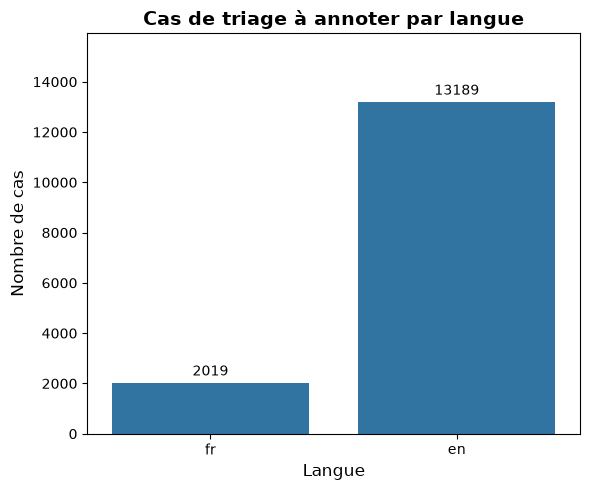

In [4]:
langues = pd.DataFrame([
    {"langue": langue, "n": sum(r["langue"] == langue for r in cas_triage)}
    for langue in ["fr", "en"]
])

fig, ax = plt.subplots(figsize=(6, 5))
create_barplot(
    langues, ax, x="langue", y="n",
    title="Cas de triage à annoter par langue",
    xlabel="Langue", ylabel="Nombre de cas",
    xrotation=0, fmt="{:.0f}",
)
plt.tight_layout()
save_figure(fig, "03_annotation_decoupage/cas_a_annoter_par_langue")
plt.show()

Les vignettes anglaises sont six fois et demie plus nombreuses que les cas français. Tout annoter déséquilibrerait fortement les langues. On annote donc tous les cas français et un tirage d'environ 3 300 vignettes anglaises, pour arriver à environ 5 000 cas de triage (40 % de français, 60 % d'anglais). La marge couvre les cas qui seront écartés après l'annotation, le filtre laissant passer du bruit.